# Step 3: Inference and Evaluation
Here we load the best-performing model (Adam usually performs well) and visually inspect tracking on our test/validation set.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import os
import random

# Re-define GIoU for loading custom metric
def giou_loss(y_true, y_pred):
    return tf.losses.mean_squared_error(y_true, y_pred) # Dummy for loading if needed, or exact logic

best_model_name = "Adam" # Change based on your plot findings
model_path = f'../models/resnet50_{best_model_name}.keras'

# Since we used a custom loss, Keras forces us to provide it on load
# Or we can compile=False if we just want to predict
model = tf.keras.models.load_model(model_path, compile=False)
print(f"Loaded {best_model_name} model successfully.")

Loaded Adam model successfully.


In [2]:
df = pd.read_csv('../data/cleaned_bounding_boxes.csv')
img_dir = '../data/training_images'

def predict_and_visualize(model, img_name):
    img_path = os.path.join(img_dir, img_name)
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return
        
    h, w = img_bgr.shape[:2]
    
    # Preprocess
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224)).astype(np.float32)
    img_processed = tf.keras.applications.resnet50.preprocess_input(img_resized)
    img_batch = np.expand_dims(img_processed, axis=0)
    
    # Predict
    pred_box = model.predict(img_batch, verbose=0)[0]
    
    # Denormalize
    pxmin, pymin, pxmax, pymax = pred_box
    pxmin, pxmax = int(pxmin * w), int(pxmax * w)
    pymin, pymax = int(pymin * h), int(pymax * h)
    
    # Get ground truth
    gt = df[df['image'] == img_name].iloc[0]
    gxmin, gymin, gxmax, gymax = int(gt['xmin']), int(gt['ymin']), int(gt['xmax']), int(gt['ymax'])
    
    # Draw Green=GT, Red=Pred
    out_img = img_rgb.copy()
    cv2.rectangle(out_img, (gxmin, gymin), (gxmax, gymax), (0, 255, 0), 2)
    cv2.putText(out_img, "GT", (gxmin, gymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    
    cv2.rectangle(out_img, (pxmin, pymin), (pxmax, pymax), (255, 0, 0), 2)
    cv2.putText(out_img, "PRED", (pxmin, pymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
    
    plt.figure(figsize=(8, 4))
    plt.imshow(out_img)
    plt.title(f"{img_name} - Green=GroundTruth | Red=Prediction")
    plt.axis('off')
    plt.show()

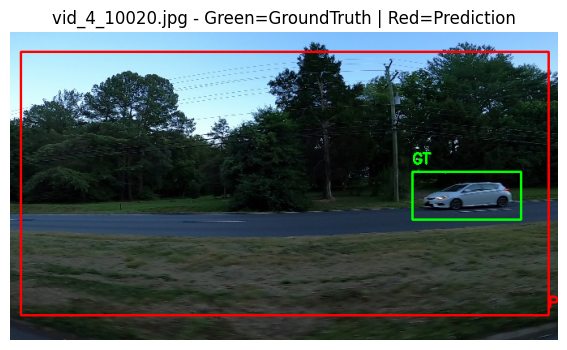

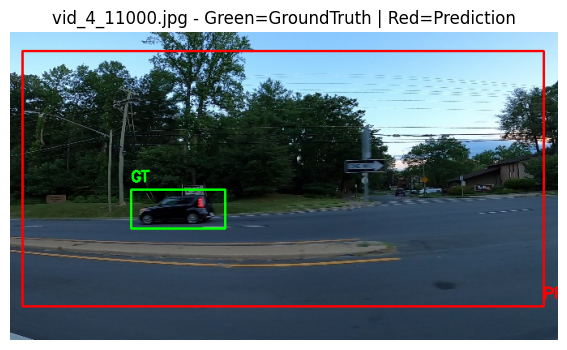

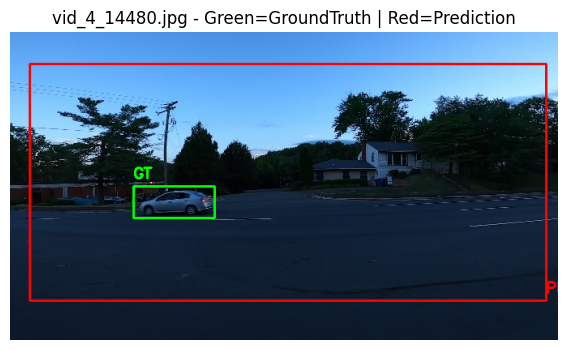

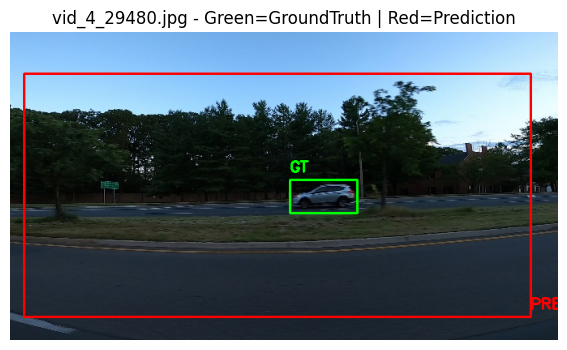

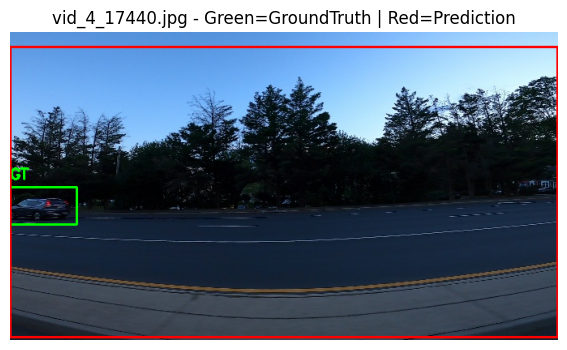

In [3]:
# Run on 5 random images
samples = np.random.choice(df['image'].values, size=5, replace=False)
for s in samples:
    predict_and_visualize(model, s)